# eBook Dataset Analysis

## Description

This project works with a small segment of Project Gutenberg’s dataset. This project is a digital library of over 70,000 free eBooks for which U.S. copyright has expired. You can find more information about the project here: https://www.gutenberg.org/.

In [2]:
import otter
grader = otter.Notebook("ebook-dataset-analysis.ipynb")

In [3]:
# RUN THIS CELL. DO NOT MODIFY. 
books = []                                                      

# reading book records from the file data.txt. 
my_file = open('data.txt', encoding='utf-8')
for line in my_file:
    books.append(line.rstrip('\n'))

- The list `books` has been populated with the data from the file `data.txt` and is available to you across this notebook.
- The list contains 80 string values, with each containing the following information about a book:
    - **Title:** Title of the book. 
    - **Author:** Authors of the book. It can be  'Various', one author, or more than one author.
    - **Release date:** Date in which the book was published. 
    - **eBook #:** Identification number of the book in the database.
    - **Language:** Language in which the book is published on the Project Gutenberg. 
    - **Credits:** Producers, editors, and all the stakeholders involved in the publication of the book. 
    - **Downloads:** Number of times the book has been downloaded from Project Gutenberg.
- All strings in the list follow the same format.
- Below is an example of how to access the first and last books in the list (run the cells below):

In [4]:
#first book
books[0]

'Title: The Extermination of the American Bison -Author: William T. Hornaday -Release date: February 10, 2006 [eBook #17748]  -Updated on: December 10, 2020 -Language: English -Credits: Produced by Chuck Greif, Tony Browne and the Online Distributed Proofreading Team at http://www.pgdp.net -Downloads: 4348'

In [5]:
#Last book
books[-1]

'Title: Taxidermy -Author: Leon Luther Pray -Release date: August 15, 2009 [eBook #29691] -Language: English -Credits: Produced by Susan Skinner and the Online Distributed Proofreading Team at http://www.pgdp.net -Downloads: 1897'

In [6]:
#lenght of the list of books
len(books)

80

# C. Questions

## Question 1:  Getting Relevant Information from a Book

Write a function that will return the title, author, release year, and the number of downloads of a book, following these instructions: 

- The function's name is `get_book_info`.
- The function takes a parameter `book`, which is a string that contains all the information about a book. For example:

<div style="width:90%; border:2px solid black; padding:10px; background:transparent;">
'Title: Taxidermy -Author: Leon Luther Pray -Release date: August 15, 2009 [eBook #29691] -Language: English -Credits: Produced by Susan Skinner and the Online Distributed Proofreading Team at http://www.pgdp.net -Downloads: 1897'.
</div>

- You will extract, from that string parameter, the required information (title, author, year, downloads) using indexing, slicing, splitting, or other string manipulation methods seen in class.
- The function will return the following data in this exact order:
    - title (string value)
    - author (string value)
    - release year (integer)
    - number of downloads (integer)
      
   For example, the return values of the book *Taxidermy* are: 'Taxidermy', 'Leon Luther Pray', 2009, and 1987. 
- If a book has multiple authors, return the entire substring containing all their names. For example:
    - For the book: *A Guide for the Study of Animals*
    - You will return as author: 'Frederic Colby Lucas Harold Brough Shinn Mabel Elizabeth Smallwood Worrallo Whitney'. 



In [7]:
def get_book_info(book: str):

    # split book by each section (title, author, downloads...)
    book_info = book.split('-')

    title: str = book_info[0].split('Title: ')[1].strip() # get title + remove whitespace
    author: str = book_info[1].split('Author: ')[1].strip() # get author + remove whitespace

    release_date: str = book_info[2].split('Release date: ')[1].split('[')[0]
    release_year: int = int(release_date.split(', ')[-1].strip()) # take last part [-1] and convert to int

    downloads: int = int(book_info[-1].split('Downloads: ')[1].strip())  # get downloads + remove whitespace

    return title, author, release_year, downloads


In [8]:
grader.check("q1")

q1 results: All test cases passed!
q1 - 1 message: Great! Your code passed this test.

## Question 2: The Digital Catalogue

Implement a function that returns a list with the first N titles of the Digital Catalogue. Consider the following: 

- A Digital Catalogue is a list of the 80 book titles sorted in alphabetical order from A to Z.
- The function name is `sorting_titles`.  
- The function receives two arguments:
   - `N` (integer): Specifies the number of elements to be returned. Using conditional statements, check that:
       - N is between 0 and 80 (inclusive), return the N elements in the list. If N is 0, return an empty list.
       - N is not in a valid range (less than 0, greater than 80), return the message "N value is not correct."
   - `asc` (boolean): Accepts True or False.
       - `asc = True`, the sorting must be done in ascending order. 
       - `asc = False`, the sorting must be done in descending order.
 

*Recommendation*: Use the previous function `get_book_info()` to extract the titles of each book in the list `books`. 


In [9]:
def sorting_titles(asc: bool, N: int):
    # create empty list for titles
    titles = []

    # return an empty list if N is 0
    if N == 0:
        return []
    # if N is between 1 and 80
    elif 1 <= N <= 80:
        # get every title
        for entry in books:
            book_info = entry.split('-Author') # each book line
            title: str = book_info[0].split('Title: ')[1].strip() # each book line title
            # add each book title to list of book titles
            titles.append(title)

        # not true = false, not false = true
        titles.sort(reverse = not asc)
        return titles[:N]

    # return if N is less than 0 and greater than 80
    else:
        return 'N value is not correct.'


In [10]:
grader.check("q2")

q2 results: All test cases passed!
q2 - 1 message: Great! Your code passed this test.

## Question 3: Sorting Titles (Improved)

Modify the previous function to allow sorting by different arguments. 

- The new function will be named `generic_sorting`.
- The arguments `asc` and `N` remain the same (including the corresponding validations).  
- The function receives a new parameter `sorting_by` to determine the sorting criteria.
   - `sorting_by` can accept only two values: 'title' or 'downloads'. 
   - If `sorting_by` is 'title', the function should return the list of titles sorted alphabetically (**exactly as Question #2**).
   - If `sorting_by` is 'downloads', the function should return the list of titles sorted by the number of downloads. 
   - If `sorting_by` is any other value,  the function should return the exact message "Invalid sort option."
- *Recommendations*:
    - Call the functions previously implemented in Q1 and Q2 (if necessary).
    - To sort a list of tuples, you can use the `key` parameter of the `.sort()` function to determine the element to consider for the sorting. For example, given the list:
    
      `my_list = [(1, 2), (4, 1), (2, 5)]`

      You can sort it  by any element of each tuple with the following command:

      `my_list.sort(key=lambda x: x[index])`

      where:
      - index `0` determines that the sorting is made considering the element of the **first** position in each tuple of the list.  
      - index `1` determines that the sorting is made considering the element of the **second** position in each tuple of the list.
      - ...
      - index `n` determines that the sorting is made considering the element of the **n+1** position in each tuple of the list.

In [11]:
def generic_sorting(asc: bool, N: int, sorting_by: str):
    book_data = [] # store book info as tuple (title, download_count)

    # return an empty list if N is 0
    if N == 0:
        return []

    # if N is between 1 and 80
    elif 1 <= N <= 80:
        for entry in books:
            book_info = entry.split('-Author')

            title: str = book_info[0].split('Title: ')[1].strip() # get title + remove whitespace
            download_count: int = int(entry.split('-Downloads:')[1].strip()) # get downloads + remove whitespace

            book_data.append((title, download_count)) # add title + downloads to book_data list

        # execute this section if sorting_by arg is title
        if sorting_by.lower() == 'title':
            # set reverse to True if asc is False, and False if asc is True
            book_data.sort(key = lambda x: x[0], reverse = not asc)
            titles = [] # results when sorting by title

            for title, download in book_data[:N]:
                titles.append(title)

            return titles # return list of titles

        # execute this section if sorting_by arg is title
        elif sorting_by.lower() == 'downloads':
            book_data.sort(key = lambda x: x[1], reverse = not asc)
            downloads = [] # results when sorting by downloads

            for title, download in book_data[:N]:
                downloads.append(title)

            return downloads # return list of downloads

        else:
            return 'Invalid sort option.'

    # return if N is less than 0 or greater than 80
    else:
        return 'N value is not correct.'


In [12]:
grader.check("q3")

q3 results: All test cases passed!
q3 - 1 message: Great! Your code passed this test.

## Question 4: What are the first 10th books in the Digital Catalogue? 

Consider that: 
- A Digital Catalogue is the list of all the book titles sorted in alphabetical order from A to Z. 
- Answer the question through coding and calling functions already implemented in this assignment. 
- To answer this question, print the list of the first 10th titles in the catalogue concatenated to the following message: "The first 10th books in the catalogue are:". For example:


  `The first 10th books in the catalogue are: ['1st title', '2nd title', '3rd title', '4th title', '5th title', '6th title', '7th title', '8th title', '9th title', '10th title'].`


In [13]:
print(f'The first 10th books in the catalogue are: {str(sorting_titles(True, 10))}.')

The first 10th books in the catalogue are: ['A Dog of Flanders', 'A Guide for the Study of Animals', 'A Hundred Anecdotes of Animals', 'A Manual of Toy Dogs: How to breed, rear, and feed them', 'ABC of Fox Hunting', 'Anecdotes of Dogs', 'Anecdotes of the Habits and Instinct of Animals', 'Animals of the Past', 'Antarctic Penguins: A Study of Their Social Habits', 'Artistic Anatomy of Animals'].


## Question 5: Getting a book's author(s)

Complete the following code to create a function `get_author_by_title` that returns the name of the author given a book title.
- The function receives the title of a book as a parameter.
- You will iterate over the collection of `books`. Once you find the title given as a parameter, you will return the corresponding author. 
- You can call functions already implemented in the assignment. 
- If the title doesn't exist, the function should return the message "Title not found."

In [14]:
def get_author_by_title(title):

    for i in range(0, len(books)):
        # if title is in the book info
        if title in books[i]:
            info: str = books[i].split('-')

            extracted_title: str = info[0].split('Title: ')[1].strip()
            # if title is the exact as title in .txt file
            if title == extracted_title:
                author: str = info[1].split('Author: ')[1].strip()

                return author

    return 'Title not found.' # return is title arg is not found


In [15]:
grader.check("q5")

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed this test.

## Question 6: Who are the authors of the 10th least popular books? 

Consider that:

- Popularity is measured by the number of downloads. A book is considered more popular than another if it has a higher number of downloads.  
- Answer the question through coding and using functions already implemented in the assignment. 
- Return the set of authors concatenated to the following message: "The 10th least popular books are authored by:"
- Authors should appear only once in the list. 

In [16]:
def popular_books():

    author_totals = {} # for storing author and download pairs

    for entry in books:

        author: str = entry.split('Author:')[1].split('-Release date:')[0].strip() # get author name
        download_line: str = entry.split('-Downloads:')[1].strip() # get download count

        downloads: int = int(download_line) # convert download count to int

        # add downloads to the authors total and initialize with 0 if author not in dict
        author_totals[author] = author_totals.get(author, 0) + downloads

    author_list = list(author_totals.items()) # convert dictionary to a list

    # sort authors by second element (total downloads) in ascending order
    sorted_authors = sorted(author_list, key=lambda x: x[1])

    first_10_pairs = sorted_authors[0:10] # store only the first 10 authors (least) downloads

    least_authors = [] # list to store just author names

    for author, downloads in first_10_pairs:
        least_authors.append(author) # add author name to list

    authors_str = ', '.join(least_authors) # join authors into a string, seperated by commas

    return 'The 10th least popular books are authored by: '+ authors_str + '.'

popular_books()

'The 10th least popular books are authored by: Robert Jennings, J. Earl Clauson, Arthur Scott Bailey, Jean-Henri Fabre, Montagu Browne, Leon Luther Pray, Elmer Harry Kreps, William J. Long, Oliver Herford, Dinks W. N. Hutchinson Edward Mayhew.'

## Question 7: Relocating Titles in the Digital Catalogue

Implement a function that relocates titles in the Digital Catalogue. Consider that:

- A Digital Catalogue is the list of the 80 book titles sorted in alphabetical order from A to Z. 
- The function name is `change_digital_catalogue`. 
- The function receives two integer arguments: `a` and `b` that represent the position of any two books in the Digital Catalogue. You can assume that the position is always given in a valid range from 0 to 79, inclusive. 
- The function will return the modified Digital Catalogue. 

To relocate two books, implement the following steps in this order: 
- Swap the first and last book of the catalogue. 
- Replace the book located in index `a` with the book located in index `b`.
- Delete the book located in `b`. 
- Insert the book previously replaced as the first element of the catalogue (use the `insert()` function).

After relocating elements, the returned list should have 80 books. 

In [17]:
# function takes integers as arguments
def change_digital_catalogue(a: int, b: int):
    # create empty list for titles
    titles = []

    # get every title
    for entry in books:
        book_info = entry.split('-Author') # each book line
        title: str = book_info[0].split('Title: ')[1].strip() # each book line title
        # add each book title to list of book titles
        titles.append(title)

    titles.sort() # sort titles in alphabetical order

    # swap the first and last books
    titles[0], titles[-1] = titles[-1], titles[0]

    replaced_book: str = titles[a] # save original book stored at index a
    titles[a] = titles[b] # swap index a book with index b book

    titles.pop(b) # remove book at index b

    titles.insert(0, replaced_book) # insert replaced book as first element in list

    return titles


In [18]:
grader.check("q7")

q7 results: All test cases passed!
q7 - 1 message: Great! Your code passed this test.

## Question 8: What is the year with the highest total number of downloads? 

Follow these instructions to answer the question:

- Implement a function `ranking_popular_years` to compute the number of downloads per release year and select the most popular year. The function does not receive any arguments. 
- The function must return the year with the highest number of downloads and the total of downloads.
- The total of downloads is the sum of all the downloads of the books released that year. 

**Hint:** Use a dictionary to count the downloads per year, with the:

     - `key`: year
     - `value`: total number of downloads for books released in that year

For example: 

        {
            1999: 1414, 
            2002: 4335, 
            ...
        }
     


In [19]:
def ranking_popular_years():
    popular_years = {} # initialize dict to store books data

    # get every release year and download
    for entry in books:
        release_date = entry.split('Release date:')[1].split('-')[0].split('[')[0].strip()
        release_year: int = int(release_date[-4:])

        downloads_line = entry.split('Downloads:')[1].strip()
        downloads: int = int(downloads_line)
        # if release year exists, and isn't None or 0
        if release_year:
            popular_years[release_year] = popular_years.get(release_year, 0) + downloads

    # create variables for max year and downloads
    max_year: int = 0
    max_downloads: int = 0

    # check every key and value in dictionary
    for year, downloads in popular_years.items():
        if downloads > max_downloads:

            max_downloads = downloads # update the max downloads each loop
            max_year = year # update the max year each loop

    return max_year, max_downloads

ranking_popular_years()

(2010, 124053)

In [20]:
grader.check("q8")

q8 results: All test cases passed!
q8 - 1 message: Great! Your code passed this test.

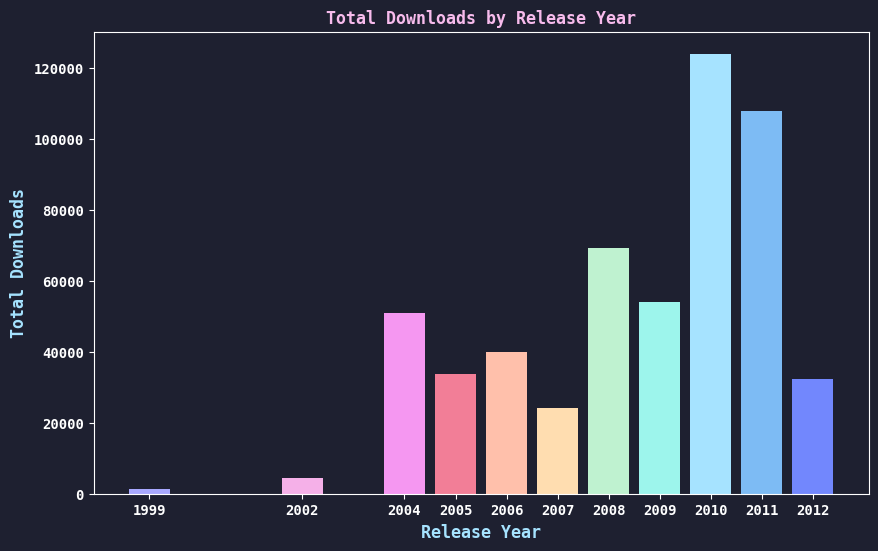

In [23]:
import os
import matplotlib.pyplot as plt

palette = ['#A8A8FF', '#f5b0e8', '#f597f1', '#f27e97', '#ffc0ab', '#ffddb0', '#bff2d0', '#9df5ec', '#a6e3ff', '#7dbbf4', '#7287fd']

popular_years: dict = {}

for entry in books:
    release_date = entry.split('Release date:')[1].split('-')[0].split('[')[0].strip()
    release_year = int(release_date[-4:])
    downloads = int(entry.split('Downloads:')[1].strip())
    popular_years[release_year] = popular_years.get(release_year, 0) + downloads

# sort by year
years = sorted(popular_years.keys())
downloads = [popular_years[i] for i in years]

# display chart
plt.figure(figsize=(10, 6), facecolor='#1E2030')
plt.tight_layout()

ax = plt.gca()
ax.set_facecolor('#1E2030')

plt.bar(years, downloads, color=palette, edgecolor='none')
plt.title('Total Downloads by Release Year', fontweight='bold', color='#f7bbec')
plt.rcParams["font.family"] = 'monospace'

plt.xlabel('Release Year', fontsize=12, fontweight='bold', color='#a6e3ff')
plt.ylabel('Total Downloads', fontsize=12, fontweight='bold', color='#a6e3ff')

plt.xticks(years, color='white', fontweight='bold')
plt.yticks(color='white', fontweight='bold')

os.makedirs('output', exist_ok=True)
plt.savefig('output/yearly_downloads.png', dpi=150, bbox_inches='tight', facecolor='#1E2030')

plt.show()

In [22]:
grader.check_all()

q1 results: All test cases passed!
q1 - 1 message: Great! Your code passed this test.

q2 results: All test cases passed!
q2 - 1 message: Great! Your code passed this test.

q3 results: All test cases passed!
q3 - 1 message: Great! Your code passed this test.

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed this test.

q7 results: All test cases passed!
q7 - 1 message: Great! Your code passed this test.

q8 results: All test cases passed!
q8 - 1 message: Great! Your code passed this test.